# Architecture alternatives — results

Factorial comparison of **basis × attention**:
`TP-DOT` (current architecture / reference), `NC-DOT`, `TP-ADD`, `NC-ADD`.

- **Level 1 (`fixed_config`)**: identical hyperparameters, outer fold 0, paired seeds.
- **Level 2 (`search`)**: shared hyperparameter grid; selection by `robust_r2 = mean_r2 − 0.25 × std_r2` (predictive only).
- **Level 3 (`confirmatory`)**: model-specific best config, 5 expanding outer folds × 5 paired seeds.

Artifacts: `results/architecture_alternatives/` from `architecture-alternatives.ipynb`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
from IPython.display import Image, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

RESULTS_DIR = Path("../results/architecture_alternatives")
FIGURES_DIR = RESULTS_DIR / "figures"
REFERENCE_MODEL = "TP-DOT"
MODEL_ORDER = ["TP-DOT", "NC-DOT", "TP-ADD", "NC-ADD"]
OWN_BOUNDS = (-5.0, 0.0)
CROSS_BOUNDS = (-1.0, 1.0)

In [2]:
def _load(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
    print(f"{path.name}: {df.shape}")
    return df

with open(RESULTS_DIR / "run_manifest.json") as f:
    manifest = json.load(f)

print(
    f"commit={manifest.get('git_commit', '')[:12]}  "
    f"device={manifest.get('device')}  "
    f"completed={manifest.get('completed_at_utc')}"
)
print("screening models:", manifest.get("screening_models"))
print("confirmatory models:", manifest.get("confirmatory_models"))

fixed_df  = _load(RESULTS_DIR / "fixed_config_runs.parquet")
search_df = _load(RESULTS_DIR / "search_runs.parquet")
outer_df  = _load(RESULTS_DIR / "outer_metrics.parquet")
elast_df  = _load(RESULTS_DIR / "elasticities.parquet")
edges_df  = _load(RESULTS_DIR / "attention_edges.parquet")
summary   = _load(RESULTS_DIR / "summary_table.csv")

for df in (fixed_df, search_df, outer_df, elast_df, edges_df):
    if "model_id" in df.columns:
        df["model_id"] = pd.Categorical(df["model_id"], MODEL_ORDER, ordered=True)

print("elasticity run_type:", elast_df["run_type"].value_counts().to_dict())
print("edge run_type:", edges_df["run_type"].value_counts().to_dict())
print("\nManifest inventory:")
print("  fixed_config runs:", manifest.get("fixed_config_substitution", {}).get("n_runs"))
print("  search runs:", manifest.get("equal_budget_search", {}).get("n_runs"))
print("  confirmatory runs:", manifest.get("outer_fold_confirmatory", {}).get("n_runs"))
print("  extraction:", manifest.get("extraction"))

commit=384de6c0b51b  device=cuda  completed=2026-09-09T17:57:56.552161+00:00
screening models: ['TP-DOT', 'NC-DOT', 'TP-ADD', 'NC-ADD']
confirmatory models: ['TP-DOT', 'NC-DOT', 'TP-ADD', 'NC-ADD']
fixed_config_runs.parquet: (20, 21)
search_runs.parquet: (96, 22)
outer_metrics.parquet: (100, 21)
elasticities.parquet: (2556660, 13)
attention_edges.parquet: (1440, 11)
summary_table.csv: (4, 11)
elasticity run_type: {'confirmatory': 2153220, 'fixed_config': 403440}
edge run_type: {'confirmatory': 1200, 'fixed_config': 240}

Manifest inventory:
  fixed_config runs: 20
  search runs: 96
  confirmatory runs: 100
  extraction: {'n_prediction_rows': 748020, 'n_elasticity_rows': 2556660, 'n_edge_rows': 1440}


## Confirmatory summary

`DeltaMAE_95CI` is versus `TP-DOT`, from a **paired** week-block bootstrap (n = 200) computed in the training notebook. If the interval covers 0, there is no detectable predictive difference at 95%.

In [3]:
display(summary)

def ci_excludes_zero(s: str) -> bool:
    # e.g. "+0.0016 [-0.0007, +0.0040]"
    inside = s.split("[", 1)[1].rstrip("]")
    lo, hi = [float(x.strip()) for x in inside.split(",")]
    return (lo > 0) or (hi < 0)

parsed = summary.copy()
parsed["ci_excludes_0"] = parsed["DeltaMAE_95CI"].map(ci_excludes_zero)
display(parsed[[
    "Modelo", "MAE", "DeltaMAE_95CI", "R2", "ci_excludes_0",
    "own_p99_abs_E", "cross_p99_abs_E", "Curvature_RMS",
    "Inter_seed_SD", "Inter_fold_SD", "Tiempo_s", "Memoria_MB",
]])

,Modelo,MAE,DeltaMAE_95CI,R2,own_p99_abs_E,cross_p99_abs_E,Curvature_RMS,Inter_seed_SD,Inter_fold_SD,Tiempo_s,Memoria_MB
0,TP-DOT,0.4588,"+0.0000 [+0.0000, +0.0000]",0.5311,8.0394,5.0564,14.3067,0.0013,0.0233,0.0013,45.7876
1,NC-DOT,0.4608,"+0.0016 [-0.0007, +0.0040]",0.5265,8.2416,2.4539,9.8644,0.0012,0.0232,0.0013,45.7887
2,TP-ADD,0.4599,"+0.0012 [-0.0000, +0.0026]",0.5308,7.4966,4.5040,14.1882,0.0010,0.0221,0.0013,45.7917
3,NC-ADD,0.4564,"-0.0022 [-0.0049, +0.0011]",0.5311,9.5906,3.1627,10.7165,0.0017,0.0242,0.0014,46.6022


,Modelo,MAE,DeltaMAE_95CI,R2,ci_excludes_0,own_p99_abs_E,cross_p99_abs_E,Curvature_RMS,Inter_seed_SD,Inter_fold_SD,Tiempo_s,Memoria_MB
0,TP-DOT,0.4588,"+0.0000 [+0.0000, +0.0000]",0.5311,False,8.0394,5.0564,14.3067,0.0013,0.0233,0.0013,45.7876
1,NC-DOT,0.4608,"+0.0016 [-0.0007, +0.0040]",0.5265,False,8.2416,2.4539,9.8644,0.0012,0.0232,0.0013,45.7887
2,TP-ADD,0.4599,"+0.0012 [-0.0000, +0.0026]",0.5308,False,7.4966,4.5040,14.1882,0.0010,0.0221,0.0013,45.7917
3,NC-ADD,0.4564,"-0.0022 [-0.0049, +0.0011]",0.5311,False,9.5906,3.1627,10.7165,0.0017,0.0242,0.0014,46.6022


## Level 1 — fixed-config substitution

Same `FIXED_CONFIG`, same reference fold (outer 0), paired seeds. Any MAE gap is an architecture effect, not a hyperparameter effect.

In [4]:
print(fixed_df.groupby("model_id", observed=True)[["r2_val", "mae_val"]].agg(["mean", "std"]))

pivot_mae = fixed_df.pivot_table(index="seed", columns="model_id", values="mae_val")
display(pivot_mae)

print("\nΔMAE vs TP-DOT (mean over seeds, fold 0):")
for m in MODEL_ORDER:
    if m == REFERENCE_MODEL:
        continue
    delta = pivot_mae[m] - pivot_mae[REFERENCE_MODEL]
    stat, p = ttest_rel(pivot_mae[m], pivot_mae[REFERENCE_MODEL])
    try:
        _, wp = wilcoxon(delta)
    except ValueError:
        wp = np.nan
    print(
        f"  {m}: mean ΔMAE={delta.mean():+.4f}  "
        f"paired t p={p:.4f}  Wilcoxon p={wp:.4f}"
    )

         r2_val        mae_val       
           mean    std    mean    std
model_id                             
TP-DOT   0.5101 0.0165  0.4816 0.0095
NC-DOT   0.5210 0.0069  0.4783 0.0057
TP-ADD   0.5122 0.0140  0.4811 0.0060
NC-ADD   0.5276 0.0152  0.4735 0.0055


model_id,TP-DOT,NC-DOT,TP-ADD,NC-ADD
seed,,,,
11,0.4816,0.4876,0.4854,0.4655
29,0.4966,0.4755,0.4764,0.4801
42,0.4829,0.4754,0.4764,0.4717
77,0.4725,0.4733,0.4777,0.4740
123,0.4746,0.4798,0.4895,0.4764



ΔMAE vs TP-DOT (mean over seeds, fold 0):
  NC-DOT: mean ΔMAE=-0.0033  paired t p=0.5485  Wilcoxon p=0.8125
  TP-ADD: mean ΔMAE=-0.0006  paired t p=0.9295  Wilcoxon p=1.0000
  NC-ADD: mean ΔMAE=-0.0081  paired t p=0.1192  Wilcoxon p=0.3125


## Level 2 — equal-budget screening

Selection is **predictive only** (`robust_r2`). `elast_score` is never used for model choice.

Best config per model (recomputed):


,cfg_id,robust_r2,mean_r2,std_r2,mean_mae
model_id,,,,,
TP-DOT,0,0.5378,0.5409,0.0127,0.4782
NC-DOT,0,0.5589,0.5629,0.0164,0.4612
TP-ADD,0,0.5372,0.5399,0.0111,0.4781
NC-ADD,2,0.5612,0.5660,0.0194,0.4601



Manifest:
  NC-ADD: cfg2  N_BASIS=9  HIDDEN=128_64  robust_r2=0.5612
  NC-DOT: cfg0  N_BASIS=3  HIDDEN=192_96  robust_r2=0.5589
  TP-ADD: cfg0  N_BASIS=3  HIDDEN=192_96  robust_r2=0.5372
  TP-DOT: cfg0  N_BASIS=3  HIDDEN=192_96  robust_r2=0.5378


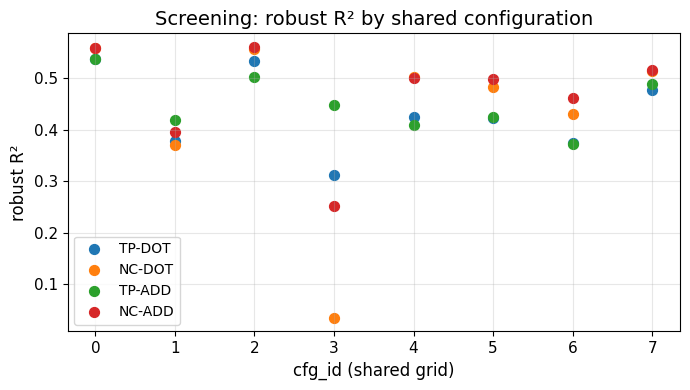

In [5]:
agg = (
    search_df.groupby(["model_id", "cfg_id"], observed=True)
    .agg(mean_r2=("r2_val", "mean"), std_r2=("r2_val", "std"),
         mean_mae=("mae_val", "mean"))
    .reset_index()
)
agg["std_r2"] = agg["std_r2"].fillna(0.0)
agg["robust_r2"] = agg["mean_r2"] - 0.25 * agg["std_r2"]

best = (
    agg.sort_values(["model_id", "robust_r2"], ascending=[True, False])
    .groupby("model_id", observed=True)
    .head(1)
    .set_index("model_id")
)
print("Best config per model (recomputed):")
display(best[["cfg_id", "robust_r2", "mean_r2", "std_r2", "mean_mae"]])

print("\nManifest:")
for mid, rec in manifest["equal_budget_search"]["best_config_per_model"].items():
    cfg = rec["config"]
    print(
        f"  {mid}: cfg{rec['cfg_id']}  N_BASIS={cfg['N_BASIS']}  "
        f"HIDDEN={cfg['HIDDEN_KEY']}  robust_r2={rec['robust_r2']:.4f}"
    )

fig, ax = plt.subplots(figsize=(7, 4))
for m in MODEL_ORDER:
    sub = agg[agg.model_id == m]
    if sub.empty:
        continue
    ax.scatter(sub["cfg_id"], sub["robust_r2"], label=m, s=50)
ax.set_xlabel("cfg_id (shared grid)")
ax.set_ylabel("robust R²")
ax.set_title("Screening: robust R² by shared configuration")
ax.legend()
fig.tight_layout()

## Level 3 — confirmatory outer folds

Each architecture uses **its own** screening winner. Gaps therefore mix architecture and hyperparameters. The paired bootstrap ΔMAE interval in the summary table is the primary test of “does fit change?”.

In [6]:
print(outer_df.groupby("model_id", observed=True)[["r2_val", "mae_val"]].agg(["mean", "std"]))

by_fold = (
    outer_df.groupby(["model_id", "fold"], observed=True)["r2_val"]
    .mean().unstack("model_id")
)
print("\nMean R² by outer fold:")
display(by_fold)

wide_mae = outer_df.pivot_table(
    index=["fold", "seed"], columns="model_id", values="mae_val"
)
print("\nPaired MAE tests vs TP-DOT (unit = fold × seed):")
for m in MODEL_ORDER:
    if m == REFERENCE_MODEL:
        continue
    delta = wide_mae[m] - wide_mae[REFERENCE_MODEL]
    _, p = ttest_rel(wide_mae[m], wide_mae[REFERENCE_MODEL])
    _, wp = wilcoxon(delta)
    print(
        f"  {m}: ΔMAE={delta.mean():+.4f}  "
        f"t p={p:.4f}  Wilcoxon p={wp:.4f}  "
        f"empirical 2.5/97.5=[{np.percentile(delta, 2.5):+.4f}, {np.percentile(delta, 97.5):+.4f}]"
    )

         r2_val        mae_val       
           mean    std    mean    std
model_id                             
TP-DOT   0.5311 0.0362  0.4588 0.0216
NC-DOT   0.5265 0.0328  0.4608 0.0216
TP-ADD   0.5308 0.0356  0.4599 0.0207
NC-ADD   0.5311 0.0331  0.4564 0.0226

Mean R² by outer fold:


model_id,TP-DOT,NC-DOT,TP-ADD,NC-ADD
fold,,,,
0,0.5248,0.5059,0.5283,0.5011
1,0.5839,0.5770,0.5840,0.5772
2,0.4764,0.4841,0.4779,0.4982
3,0.5456,0.5369,0.5438,0.5549
4,0.5249,0.5285,0.5200,0.5244



Paired MAE tests vs TP-DOT (unit = fold × seed):
  NC-DOT: ΔMAE=+0.0020  t p=0.2196  Wilcoxon p=0.1817  empirical 2.5/97.5=[-0.0113, +0.0166]
  TP-ADD: ΔMAE=+0.0011  t p=0.4255  Wilcoxon p=0.3810  empirical 2.5/97.5=[-0.0118, +0.0143]
  NC-ADD: ΔMAE=-0.0025  t p=0.1903  Wilcoxon p=0.1485  empirical 2.5/97.5=[-0.0202, +0.0167]


In [7]:
def factors(model_id: str) -> pd.Series:
    basis, score = str(model_id).split("-")
    return pd.Series({"basis": basis, "score": score})

fac = pd.concat([outer_df, outer_df["model_id"].astype(str).apply(factors)], axis=1)

print("Mean MAE by factor (confirmatory):")
display(fac.groupby(["basis", "score"], observed=True)["mae_val"].mean().unstack())
print("Mean R² by factor:")
display(fac.groupby(["basis", "score"], observed=True)["r2_val"].mean().unstack())

cell = fac.groupby(["basis", "score"], observed=True)["mae_val"].mean()
print(
    "\nMain effect NC vs TP (avg. over score):",
    cell.xs("NC", level="basis").mean() - cell.xs("TP", level="basis").mean(),
)
print(
    "Main effect ADD vs DOT (avg. over basis):",
    cell.xs("ADD", level="score").mean() - cell.xs("DOT", level="score").mean(),
)

Mean MAE by factor (confirmatory):


score,ADD,DOT
basis,,
NC,0.4564,0.4608
TP,0.4599,0.4588


Mean R² by factor:


score,ADD,DOT
basis,,
NC,0.5311,0.5265
TP,0.5308,0.5311



Main effect NC vs TP (avg. over score): -0.0007858723402023315
Main effect ADD vs DOT (avg. over basis): -0.001666901707649271


## Elasticities (confirmatory)

Design ranges: own ∈ [−5, 0], cross ∈ [−1, 1].  
`own_p99_abs_E` / `cross_p99_abs_E` measure tails. `Curvature_RMS` is the **natural-cubic** hypothesis (linear extrapolation instead of cubic blow-up outside the training support).

,model_id,type,n,median,iqr,p99_abs,pct_in_range,pct_negative,pct_near_bound
0,TP-DOT,cross,381650,0.1170,0.3489,5.0564,0.8843,NaN,0.0665
1,TP-DOT,own,156655,-0.2597,1.4732,8.0394,0.8177,0.8956,0.4364
2,NC-DOT,cross,381650,0.0863,0.3828,2.4539,0.9190,NaN,0.0799
3,NC-DOT,own,156655,-0.6762,2.1820,8.2416,0.8111,0.8896,0.3095
4,TP-ADD,cross,381650,0.1340,0.3223,4.5040,0.8957,NaN,0.0660
5,TP-ADD,own,156655,-0.1999,1.2896,7.4966,0.8097,0.8806,0.4445
6,NC-ADD,cross,381650,-0.0956,0.3862,3.1627,0.8809,NaN,0.0974
7,NC-ADD,own,156655,-1.7177,1.8017,9.5906,0.9088,0.9923,0.0435


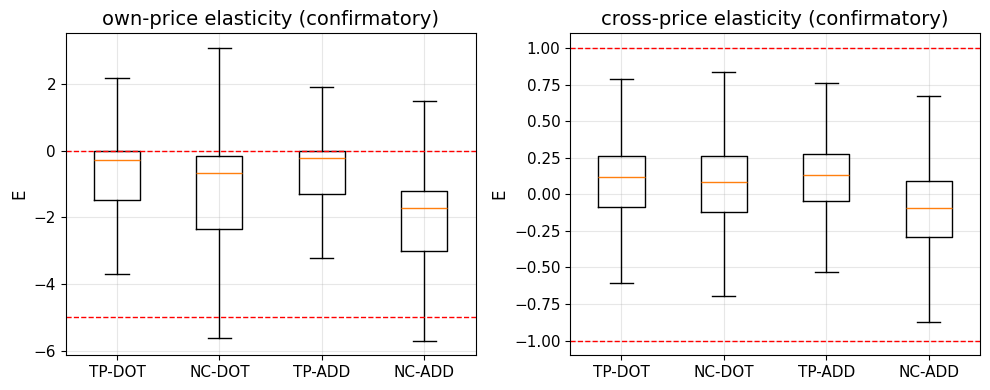

In [8]:
conf_e = elast_df[elast_df["run_type"] == "confirmatory"].copy()

rows = []
for (m, t), g in conf_e.groupby(["model_id", "type"], observed=True):
    lo, hi = OWN_BOUNDS if t == "own" else CROSS_BOUNDS
    near = (np.abs(g["E"] - lo) < 0.25) | (np.abs(g["E"] - hi) < 0.25)
    rows.append({
        "model_id": m, "type": t, "n": len(g),
        "median": float(g["E"].median()),
        "iqr": float(g["E"].quantile(0.75) - g["E"].quantile(0.25)),
        "p99_abs": float(g["E"].abs().quantile(0.99)),
        "pct_in_range": float(((g["E"] >= lo) & (g["E"] <= hi)).mean()),
        "pct_negative": float((g["E"] < 0).mean()) if t == "own" else np.nan,
        "pct_near_bound": float(near.mean()),
    })
diag_e = pd.DataFrame(rows)
display(diag_e)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, bounds in zip(axes, ["own", "cross"], [OWN_BOUNDS, CROSS_BOUNDS]):
    data = [
        conf_e.loc[(conf_e.model_id == m) & (conf_e.type == t), "E"].to_numpy()
        for m in MODEL_ORDER
    ]
    ax.boxplot(data, tick_labels=MODEL_ORDER, showfliers=False)
    ax.axhline(bounds[0], color="red", ls="--", lw=1)
    ax.axhline(bounds[1], color="red", ls="--", lw=1)
    ax.set_title(f"{t}-price elasticity (confirmatory)")
    ax.set_ylabel("E")
fig.tight_layout()

## Attention graph (top-k Jaccard)

Neighbor-set stability across **seeds** (fold held fixed) and **folds** (seed held fixed). Additive vs scaled-dot scoring is the second architectural hypothesis.

In [9]:
def edge_set_by_product(df, model_id, fold=None, seed=None, run_type="confirmatory"):
    d = df[(df.model_id == model_id) & (df.run_type == run_type)]
    if fold is not None:
        d = d[d.fold == fold]
    if seed is not None:
        d = d[d.seed == seed]
    return d.groupby("i_idx")["j_idx"].apply(lambda s: frozenset(s.tolist())).to_dict()

def jaccard(a, b):
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

def mean_jaccard_across(df, model_id, group_col, fixed_col, fixed_val):
    values = sorted(df.loc[
        (df.model_id == model_id) & (df[fixed_col] == fixed_val), group_col
    ].unique())
    if len(values) < 2:
        return np.nan
    scores = []
    for i, va in enumerate(values):
        for vb in values[i + 1:]:
            sa = edge_set_by_product(df, model_id, **{fixed_col: fixed_val, group_col: va})
            sb = edge_set_by_product(df, model_id, **{fixed_col: fixed_val, group_col: vb})
            for k in set(sa) | set(sb):
                scores.append(jaccard(sa.get(k, frozenset()), sb.get(k, frozenset())))
    return float(np.mean(scores)) if scores else np.nan

conf_edges = edges_df[edges_df.run_type == "confirmatory"]
jac_rows = []
for model_id in MODEL_ORDER:
    d = conf_edges[conf_edges.model_id == model_id]
    if d.empty:
        continue
    for fold in sorted(d["fold"].unique()):
        jac_rows.append({
            "model_id": model_id, "axis": "seeds", "fixed_value": fold,
            "mean_jaccard": mean_jaccard_across(conf_edges, model_id, "seed", "fold", fold),
        })
    for seed in sorted(d["seed"].unique()):
        jac_rows.append({
            "model_id": model_id, "axis": "folds", "fixed_value": seed,
            "mean_jaccard": mean_jaccard_across(conf_edges, model_id, "fold", "seed", seed),
        })

jac_df = pd.DataFrame(jac_rows)
print(jac_df.groupby(["model_id", "axis"])["mean_jaccard"].mean().unstack())

entropy = (
    conf_edges.groupby("model_id", observed=True)
    .agg(mean_entropy=("mean_entropy_i", "mean"),
         mean_max_weight=("mean_max_weight_i", "mean"))
    .reindex(MODEL_ORDER)
)
display(entropy)

axis      folds  seeds
model_id              
NC-ADD   1.0000 1.0000
NC-DOT   1.0000 1.0000
TP-ADD   1.0000 1.0000
TP-DOT   1.0000 1.0000


,mean_entropy,mean_max_weight
model_id,,
TP-DOT,0.7557,0.5497
NC-DOT,0.7312,0.5696
TP-ADD,0.7775,0.5360
NC-ADD,0.7978,0.4924


In [10]:
rt = (
    outer_df.groupby("model_id", observed=True)
    .agg(
        candidate_s=("candidate_scoring_time_s", "mean"),
        frozen_s=("frozen_graph_time_s", "mean"),
        mem_mb=("peak_gpu_memory_mb", "mean"),
    )
)
rt["speedup_frozen"] = rt["candidate_s"] / rt["frozen_s"]
display(rt)

,candidate_s,frozen_s,mem_mb,speedup_frozen
model_id,,,,
TP-DOT,0.0018,0.0013,45.7876,1.3496
NC-DOT,0.0019,0.0013,45.7887,1.4253
TP-ADD,0.0018,0.0013,45.7917,1.3751
NC-ADD,0.0020,0.0014,46.6022,1.3782


## Experiment figures

PNG exports from the training notebook. `05_curvature_vs_support.png` cannot be rebuilt here: per-run `basis_diag` was not persisted (only the aggregated `Curvature_RMS` in `summary_table.csv`).

../results/architecture_alternatives/figures/01_mae_ci.png


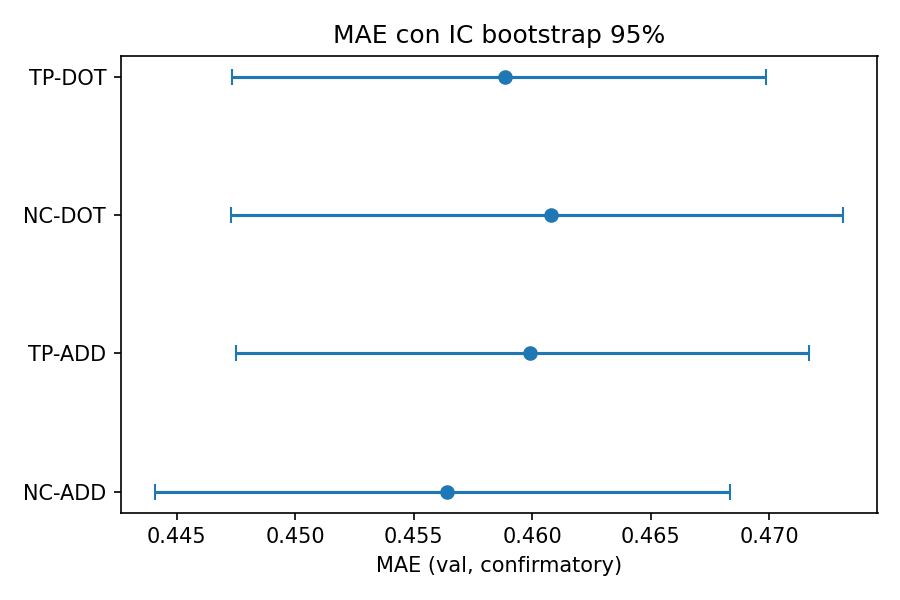

../results/architecture_alternatives/figures/02_delta_mae_forest.png


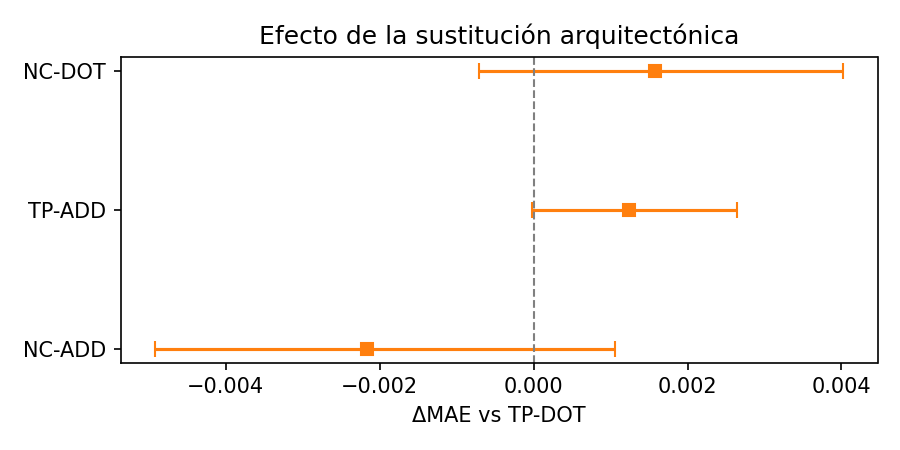

../results/architecture_alternatives/figures/03_r2_by_fold.png


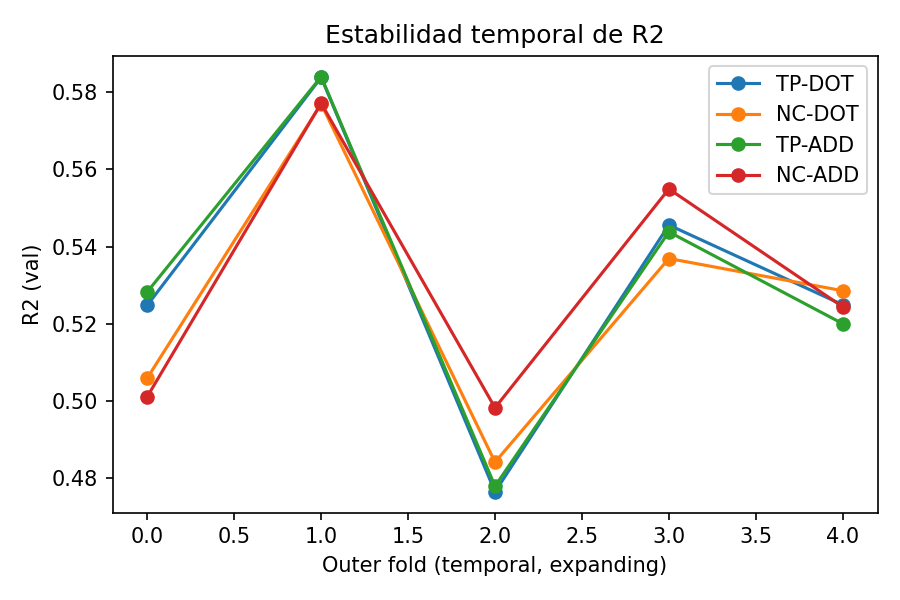

../results/architecture_alternatives/figures/04_elasticity_distributions.png


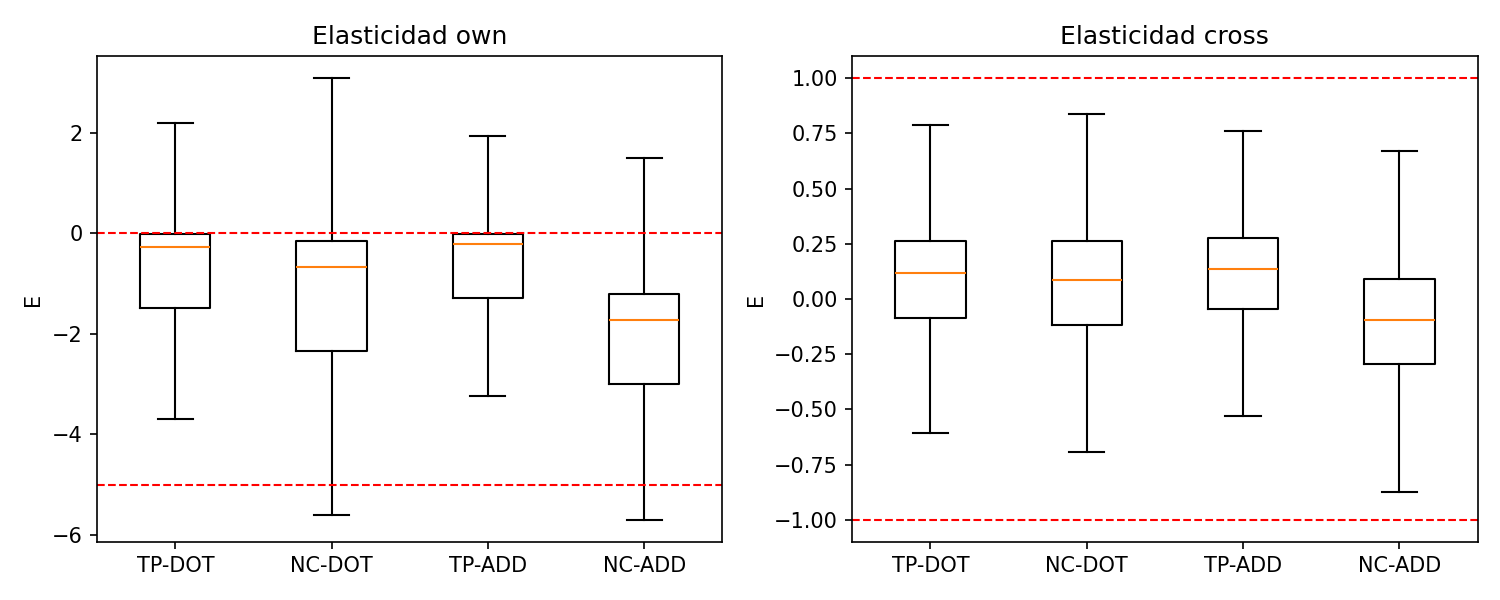

../results/architecture_alternatives/figures/05_curvature_vs_support.png


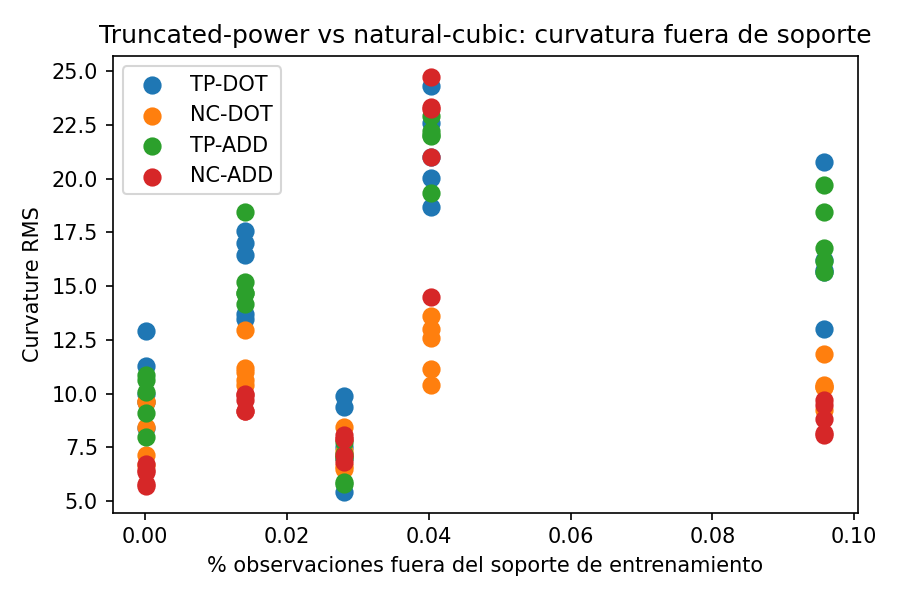

../results/architecture_alternatives/figures/06_attention_jaccard.png


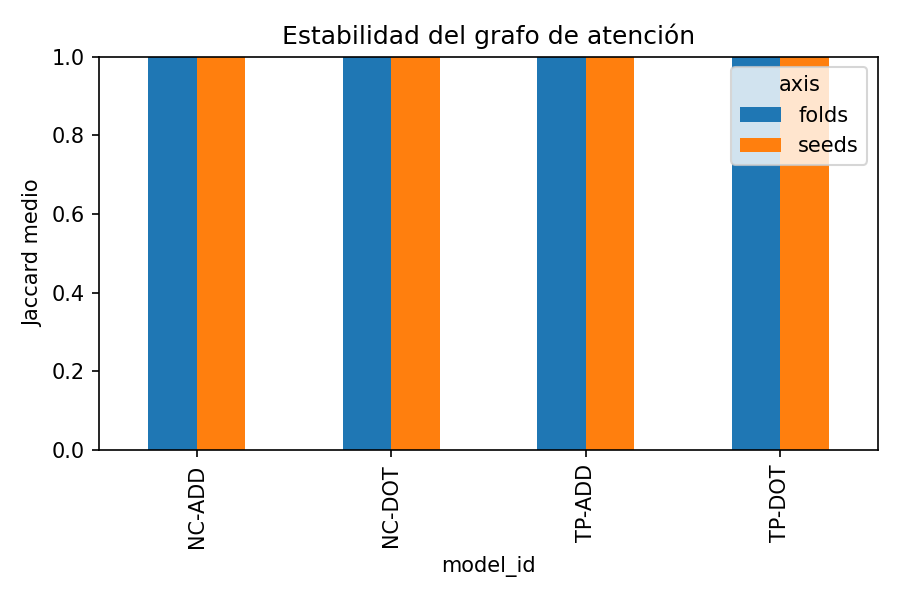

../results/architecture_alternatives/figures/07_runtime_memory.png


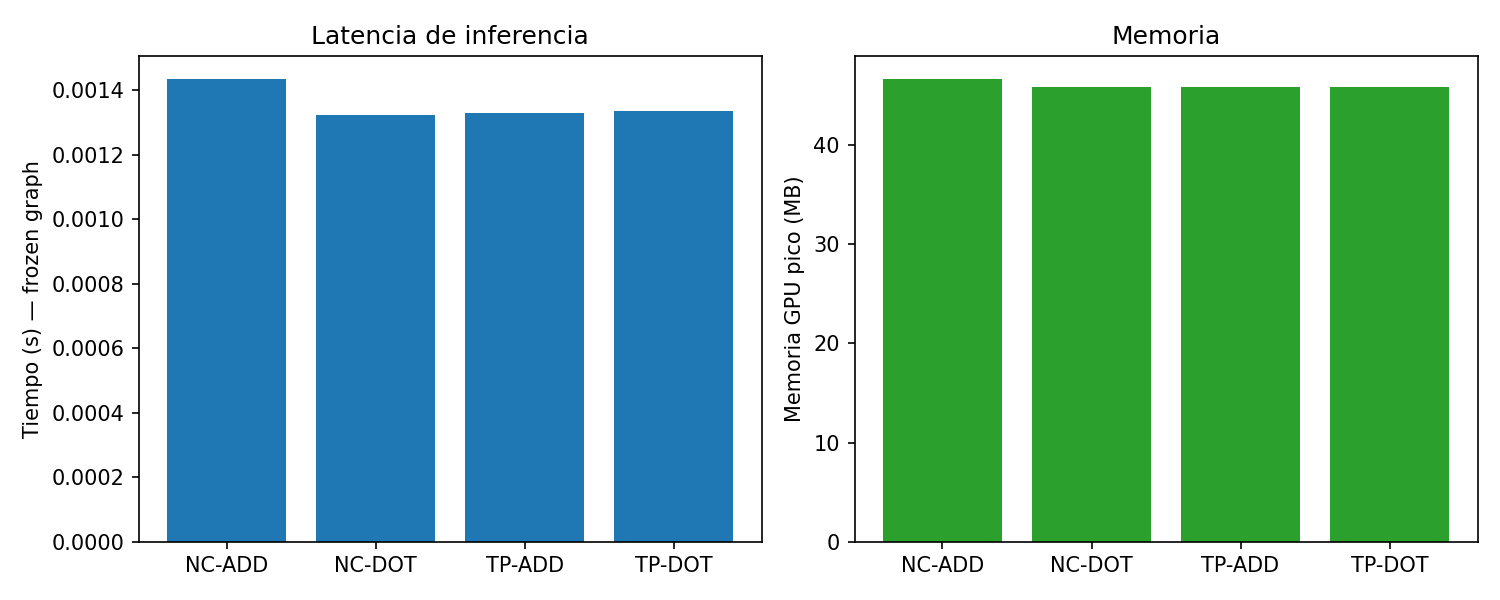

In [11]:
for name in [
    "01_mae_ci.png",
    "02_delta_mae_forest.png",
    "03_r2_by_fold.png",
    "04_elasticity_distributions.png",
    "05_curvature_vs_support.png",
    "06_attention_jaccard.png",
    "07_runtime_memory.png",
]:
    p = FIGURES_DIR / name
    print(p)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print("  (missing)")